##### Linear Regression Model
Last edit: Nemo, 11/3 11:53

##### Import Libraries

In [11]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import altair as alt

from viz_utils import create_prediction_chart, create_prediction_error_chart
alt.data_transformers.enable('default', max_rows=None)

DataTransformerRegistry.enable('default')

##### Import master_df

In [12]:
# Load the master_df
master_df = pd.read_csv("master_df.csv")
master_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5219 entries, 0 to 5218
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         5219 non-null   object 
 1   ('Close', 'IWM')   5219 non-null   float64
 2   ('Close', 'QQQ')   5219 non-null   float64
 3   ('Close', 'SPY')   5219 non-null   float64
 4   ('High', 'IWM')    5219 non-null   float64
 5   ('High', 'QQQ')    5219 non-null   float64
 6   ('High', 'SPY')    5219 non-null   float64
 7   ('Low', 'IWM')     5219 non-null   float64
 8   ('Low', 'QQQ')     5219 non-null   float64
 9   ('Low', 'SPY')     5219 non-null   float64
 10  ('Open', 'IWM')    5219 non-null   float64
 11  ('Open', 'QQQ')    5219 non-null   float64
 12  ('Open', 'SPY')    5219 non-null   float64
 13  ('Volume', 'IWM')  5219 non-null   float64
 14  ('Volume', 'QQQ')  5219 non-null   float64
 15  ('Volume', 'SPY')  5219 non-null   float64
 16  VIX                5219 

#####


In [13]:
# Convert first column to datetime and set as index
master_df['Unnamed: 0'] = pd.to_datetime(master_df['Unnamed: 0'])
master_df = master_df.rename(columns={'Unnamed: 0': 'Date'})
master_df = master_df.reset_index(drop=True)

# Clean up the column names - remove tuples and create simpler names
new_columns = []
for col in master_df.columns:
    if col[0] == "(":
        # Remove parentheses and split
        clean_col = col.strip('()').replace("'", "").replace('"', '')
        parts = clean_col.split(', ')
        # Format as 'IWM_Close'
        new_columns.append(f"{parts[1]}_{parts[0]}")
    else:
        new_columns.append(col)

master_df.columns = new_columns

master_df.head()

,Date,IWM_Close,QQQ_Close,SPY_Close,IWM_High,QQQ_High,SPY_High,IWM_Low,QQQ_Low,SPY_Low,IWM_Open,QQQ_Open,SPY_Open,IWM_Volume,QQQ_Volume,SPY_Volume,VIX
0,2005-01-03,48.436901,33.738796,81.847145,49.422161,34.413573,82.840468,48.179218,33.627756,81.575001,49.335005,34.242743,82.704393,16062600.0,100970900.0,55748000.0,14.08
1,2005-01-04,47.398605,33.123806,80.846985,48.569548,33.943789,82.010397,47.315237,32.927353,80.581646,48.531657,33.883996,81.955967,27450000.0,136623200.0,69167600.0,13.98
2,2005-01-05,46.451225,32.918808,80.289101,47.474379,33.277548,81.132744,46.451225,32.859018,80.282296,47.345539,33.038388,80.785759,29884200.0,127925500.0,65667300.0,14.09
3,2005-01-06,46.697544,32.756527,80.697296,47.140910,33.064020,81.064690,46.401964,32.747987,80.459172,46.739226,32.995690,80.581636,23061200.0,102934600.0,47814700.0,13.58
4,2005-01-07,46.178394,32.927345,80.581650,46.951445,33.200672,81.119134,46.151868,32.636935,80.370735,46.803656,32.935889,80.942239,20906200.0,123104000.0,55847700.0,13.49


In [14]:
# check for basic info
master_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5219 entries, 0 to 5218
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Date        5219 non-null   datetime64[ns]
 1   IWM_Close   5219 non-null   float64       
 2   QQQ_Close   5219 non-null   float64       
 3   SPY_Close   5219 non-null   float64       
 4   IWM_High    5219 non-null   float64       
 5   QQQ_High    5219 non-null   float64       
 6   SPY_High    5219 non-null   float64       
 7   IWM_Low     5219 non-null   float64       
 8   QQQ_Low     5219 non-null   float64       
 9   SPY_Low     5219 non-null   float64       
 10  IWM_Open    5219 non-null   float64       
 11  QQQ_Open    5219 non-null   float64       
 12  SPY_Open    5219 non-null   float64       
 13  IWM_Volume  5219 non-null   float64       
 14  QQQ_Volume  5219 non-null   float64       
 15  SPY_Volume  5219 non-null   float64       
 16  VIX         5219 non-nul

In [24]:
df = master_df.copy()

# Feature: Momentum only (e.g., 5-day returns)
df['momentum_5d'] = df['SPY_Close'].pct_change(5)

# Target: Future return (e.g., next day)
df['target_future_return'] = df['SPY_Close'].pct_change().shift(-1)

# Drop NaN values created by pct_change
df_clean = df[['Date', 'momentum_5d', 'target_future_return']].dropna()

# Split features (X) and target (y)
X = df_clean[['momentum_5d']]
y = df_clean['target_future_return']

# Train the model
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

# Model coefficients
print(f"Intercept: {model.intercept_:.6f}")
print(f"Coefficient: {model.coef_[0]:.4f}")
print(f"R-squared: {r2_score(y, y_pred):.4f}")

Intercept: 0.000567
Coefficient: -0.0390
R-squared: 0.0061


C:\Users\puyan\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


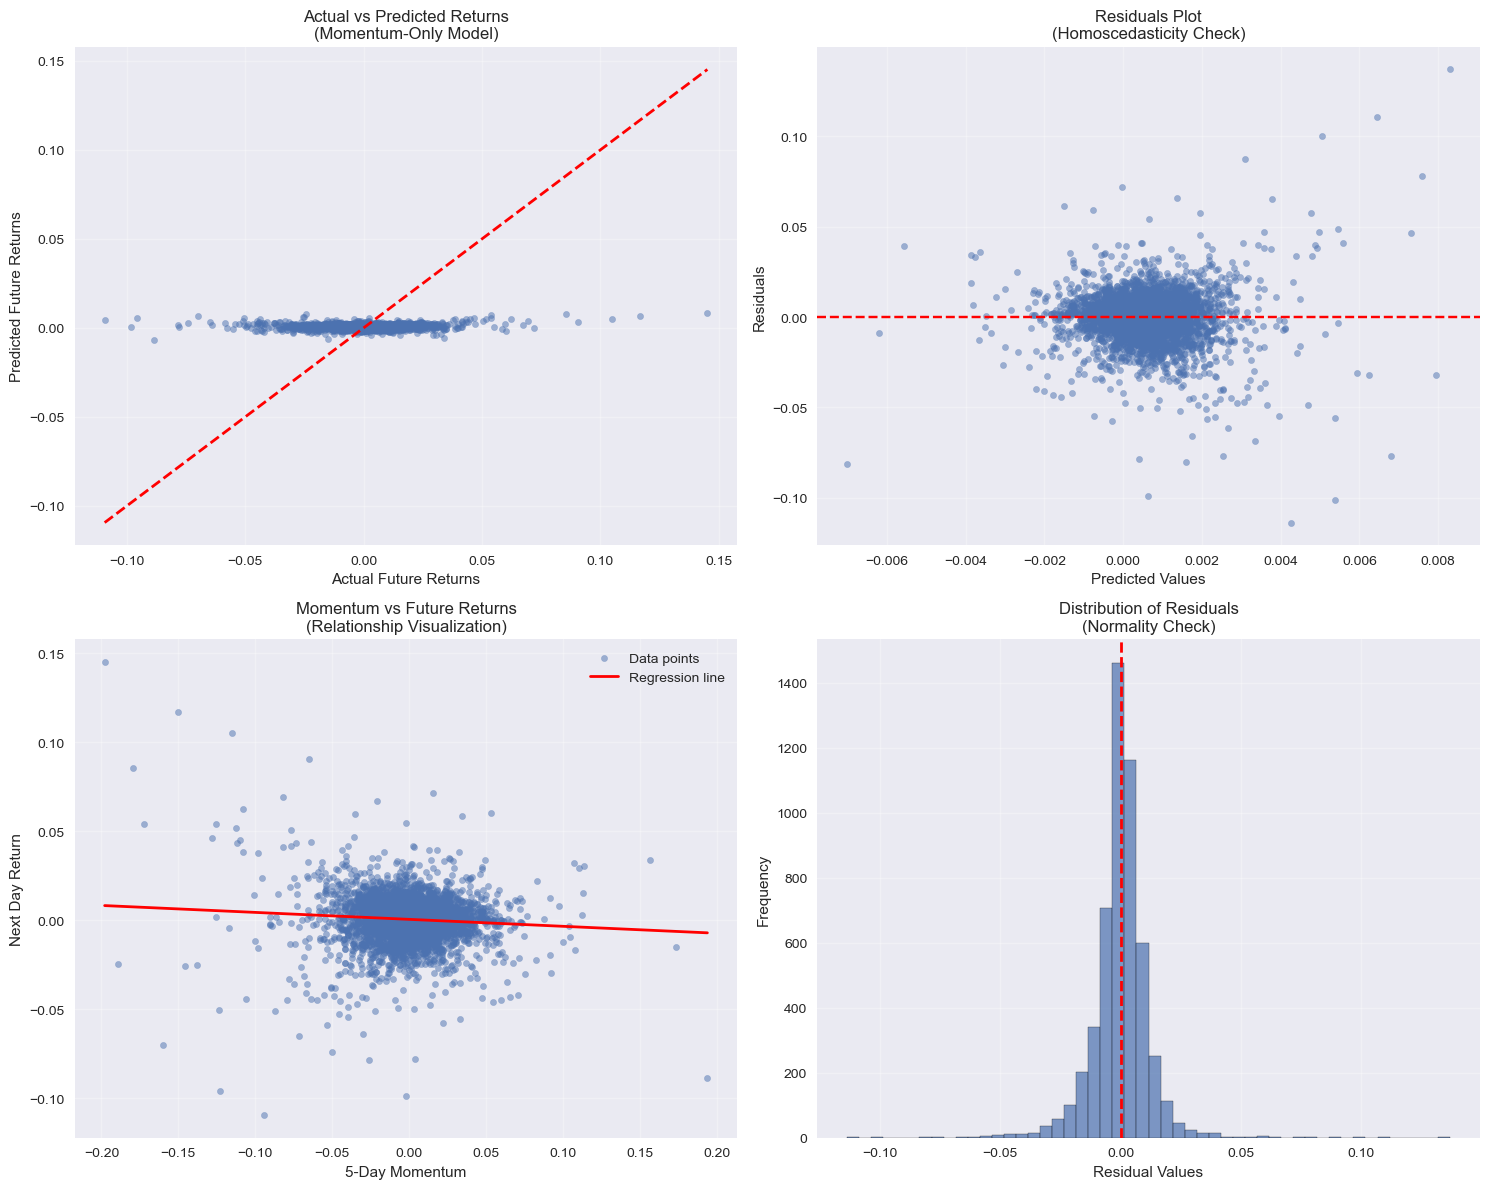

In [25]:
# Set up the plotting style
plt.style.use('seaborn-v0_8')
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Actual vs Predicted Scatter
axes[0,0].scatter(y, y_pred, alpha=0.5, s=20)
axes[0,0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
axes[0,0].set_xlabel('Actual Future Returns')
axes[0,0].set_ylabel('Predicted Future Returns')
axes[0,0].set_title('Actual vs Predicted Returns\n(Momentum-Only Model)')
axes[0,0].grid(True, alpha=0.3)

# Plot 2: Residuals Plot
residuals = y - y_pred
axes[0,1].scatter(y_pred, residuals, alpha=0.5, s=20)
axes[0,1].axhline(y=0, color='r', linestyle='--')
axes[0,1].set_xlabel('Predicted Values')
axes[0,1].set_ylabel('Residuals')
axes[0,1].set_title('Residuals Plot\n(Homoscedasticity Check)')
axes[0,1].grid(True, alpha=0.3)

# Plot 3: Momentum vs Future Returns (with regression line)
axes[1,0].scatter(X['momentum_5d'], y, alpha=0.5, s=20, label='Data points')
# Create regression line
x_line = np.linspace(X['momentum_5d'].min(), X['momentum_5d'].max(), 100)
y_line = model.predict(x_line.reshape(-1, 1))
axes[1,0].plot(x_line, y_line, 'r-', lw=2, label='Regression line')
axes[1,0].set_xlabel('5-Day Momentum')
axes[1,0].set_ylabel('Next Day Return')
axes[1,0].set_title('Momentum vs Future Returns\n(Relationship Visualization)')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# Plot 4: Distribution of Residuals
axes[1,1].hist(residuals, bins=50, alpha=0.7, edgecolor='black')
axes[1,1].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[1,1].set_xlabel('Residual Values')
axes[1,1].set_ylabel('Frequency')
axes[1,1].set_title('Distribution of Residuals\n(Normality Check)')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [26]:
print("Data check:")
print(f"y shape: {y.shape}, NaN count: {pd.isna(y).sum()}")
print(f"y_pred shape: {y_pred.shape}, NaN count: {pd.isna(y_pred).sum()}")
print(f"y sample: {y[:5]}")
print(f"y_pred sample: {y_pred[:5]}")

Data check:
y shape: (5213,), NaN count: 0
y_pred shape: (5213,), NaN count: 0
y sample: 5   -0.006891
6    0.003300
7   -0.008012
8    0.005271
9    0.010402
Name: target_future_return, dtype: float64
y_pred sample: [0.00098927 0.00078092 0.00038205 0.00089322 0.00063326]


In [66]:
def create_prediction_chart(actual_values, predicted_values, dates=None, chart_title="Prediction Results"):
    import numpy as np
    import pandas as pd
    import altair as alt

    # Convert inputs
    y_clean = np.array(actual_values).copy()
    y_pred_clean = np.array(predicted_values).copy()

    if dates is not None and len(dates) != len(y_clean):
        raise ValueError("Length of dates must match actual and predicted values.")

    print(f"📊 Actual range: {y_clean.min():.6f} to {y_clean.max():.6f}")
    print(f"📊 Predicted range: {y_pred_clean.min():.6f} to {y_pred_clean.max():.6f}")

    # Build base DataFrame
    plot_data = pd.DataFrame({
        'time_index': range(len(y_clean)),
        'actual': y_clean,
        'predicted': y_pred_clean
    })
    if dates is not None:
        plot_data['date'] = pd.to_datetime(dates)

    melted_data = pd.melt(
        plot_data,
        id_vars=['time_index', 'date'] if 'date' in plot_data.columns else ['time_index'],
        value_vars=['actual', 'predicted'],
        var_name='series_type',
        value_name='value'
    )

    # Choose proper x field
    x_field = 'date:T' if 'date' in melted_data.columns else 'time_index:Q'
    hover_field = 'date' if 'date' in melted_data.columns else 'time_index'

    # --- Selections ---
    brush = alt.selection_interval(encodings=['x'])  # Altair 5
    hover = alt.selection_point(
        fields=[hover_field],
        nearest=True,
        on='mouseover',
        empty=False,
        clear='mouseout'
    )

    # --- Base chart ---
    base = (
        alt.Chart(melted_data)
        .encode(
            x=alt.X(x_field, title=None),
            y=alt.Y('value:Q', title='Returns', scale=alt.Scale(zero=False)),
            color=alt.Color(
                'series_type:N',
                title='Series',
                scale=alt.Scale(domain=['actual', 'predicted'],
                                range=['#1f77b4', '#ff7f0e'])
            )
        )
    )

    # --- Lines ---
    lines = base.mark_line().encode(opacity=alt.value(0.9))

    # --- Vertical hover rule ---
    rule = (
        alt.Chart(melted_data)
        .mark_rule(color='gray', strokeWidth=1)
        .encode(x=x_field)
        .transform_filter(hover)
    )

    # --- Text labels (actual + predicted values) ---
    text = (
        alt.Chart(melted_data)
        .mark_text(align='left', dx=5, dy=-5)
        .encode(
            x=x_field,
            text=alt.condition(
                hover,
                alt.Text('value:Q', format='.4f'),
                alt.value('')
            ),
            color='series_type:N'
        )
        .transform_filter(hover)
    )

    # --- Upper interactive chart ---
    upper = (
        alt.layer(lines, rule, text)
        .properties(width=800, height=350)
        .add_params(hover)
        .transform_filter(brush)
    )

    # --- Lower slider (overview) ---
    lower = (
        alt.Chart(melted_data)
        .mark_line()
        .encode(
            x=alt.X(x_field, title='Time Range'),
            y=alt.Y('value:Q', title=None, scale=alt.Scale(zero=False)),
            color=alt.Color('series_type:N', legend=None,
                            scale=alt.Scale(domain=['actual', 'predicted'],
                                            range=['#1f77b4', '#ff7f0e']))
        )
        .properties(width=800, height=100)
        .add_params(brush)
    )

    # --- Final composition ---
    chart = (
        alt.vconcat(upper, lower)
        .properties(title=chart_title)
        .configure_title(fontSize=16, anchor='start')
    )

    return chart


In [68]:
# Plot 1: Standard comparison (might still show small predictions)
chart1 = create_prediction_chart(y, y_pred, df_clean['Date'], "Momentum Only: Linear Regression Model Results")

chart1

📊 Actual range: -0.109424 to 0.145198
📊 Predicted range: -0.007009 to 0.008296


alt.VConcatChart(...)